# W1 waveguide transmittance

`waveguide_w1.py` の notebook 版です。`fig/` と `out/` は、この notebook を実行しているカレントディレクトリ配下に作成されます。

In [ ]:
import time
import math
from pathlib import Path

import meep as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fs = 18
plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': fs,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})

Using MPI version 4.1, 1 processes


In [2]:
notebook_dir = Path.cwd()
fig_dir = notebook_dir / "fig"
out_dir = notebook_dir / "out"
fig_dir.mkdir(exist_ok=True)
out_dir.mkdir(exist_ok=True)

fig_dir, out_dir

(PosixPath('/Users/uemura/repositories/physics/pymeep_for_phc/waveguide/waveguide_w1/fig'),
 PosixPath('/Users/uemura/repositories/physics/pymeep_for_phc/waveguide/waveguide_w1/out'))

In [3]:
def phc_trans(use_photonic_crystal=True, photonic_crystal_length=100, decay_check=0, decay_time=500):
    """
    <変数の説明>
    PhC...PhC(フォトニック結晶)を配置するかどうか。Falseで直線導波路
    photonic_crystal_length...PhC導波方向の長さ
    photonic_crystal_width...PhC垂直方向の幅。PMLと被ってるので適当。
    connection_waveguide...PhCに接続するSi導波路(棒の部分)の長さ
    wgi...導波路の幅を調整する。1で丸穴一個分空いてることを意味する。0.7とかにすると狭くなってバンドの形が変わる、っていうのはDaii君の研究とも絡む。
    r...穴の半径。ふつうはa/4くらい。meepだと格子定数は1で固定だから、格子定数との比を入力すればOK
    n_eff...屈折率。2次元だと2.5~2.7くらいにしておくと3次元のSi系(n_si=3.48)と結果が近くなる。違う材料を使うときは要調整、通常はdefaultで大丈夫。
    fcen...入力光（ガウシアンビーム）の中心周波数。知りたいPhCバンドの周波数近くに設定する
    df...入力光（ガウシアンビーム）の半値幅（で合ってる？）
    nfreq...入力光（ガウシアンビーム）のきめ細かさ
    resolution...メッシュの細かさ。2^nにすると計算が軽くなるらしい。
    decay_time...反復計算数。小さいと誤差が増え、大きいと時間がかかる。sim.run(until_after_sources=...)で計算時間を見積もってから変えるとよさそう
    decay_check...解の収束をどこで判定するか、位置を指定。defaultでOK

    <備考>
    ・meepでは格子定数aはパラメータに含まれないので設定不要
    　誘電体を使うときは入力するらしい（スケール依存性が出るから）
    ・THzやnmは使用せず、すべて規格化周波数で入力する (周波数はωa/2πcで直す)
    """
    ##### setting of parameters #####
    photonic_crystal_width = 10
    connection_waveguide = 5
    wgi = 1
    r = 1 / 4
    n_eff = 2.6
    fcen = 0.3
    df = 0.1
    nfreq = 500  # number of frequencies at which to compute flux
    resolution = 16

    length = photonic_crystal_length + 2 * connection_waveguide
    width = photonic_crystal_width
    nx = int(photonic_crystal_length)
    ny = int(photonic_crystal_width)
    eps = n_eff**2

    ##### settings of geometry #####
    cell = mp.Vector3(length, width * np.sqrt(3), 0)

    waveguide = mp.Block(
        mp.Vector3(mp.inf, wgi * np.sqrt(3), mp.inf),
        center=mp.Vector3(),
        material=mp.Medium(epsilon=eps),
    )
    geometry = [waveguide]

    if use_photonic_crystal:
        blk = mp.Block(
            mp.Vector3(photonic_crystal_length, photonic_crystal_width * np.sqrt(3), mp.inf),
            center=mp.Vector3(),
            material=mp.Medium(epsilon=eps),
        )
        geometry.append(blk)

        for j in range(ny):
            for i in range(nx + 1):
                shift_y = np.sqrt(3)
                geometry.append(mp.Cylinder(r, center=mp.Vector3(i - nx / 2, wgi * np.sqrt(3) / 2 + shift_y * j)))
                geometry.append(mp.Cylinder(r, center=mp.Vector3(i - nx / 2, -(wgi * np.sqrt(3) / 2 + shift_y * j))))

                geometry.append(mp.Cylinder(r, center=mp.Vector3(i - (nx + 1) / 2, wgi * np.sqrt(3) / 2 + shift_y * (j + 1 / 2))))
                geometry.append(mp.Cylinder(r, center=mp.Vector3(i - (nx + 1) / 2, -(wgi * np.sqrt(3) / 2 + shift_y * (j + 1 / 2)))))

    sources = [
        mp.Source(
            mp.GaussianSource(fcen, fwidth=df),
            component=mp.Hz,
            center=mp.Vector3(-length / 2 + 1, 0),
            size=mp.Vector3(0, wgi * np.sqrt(3)),
        )
    ]

    pml_layers = [mp.PML(1.0)]
    sym = [mp.Mirror(mp.Y, phase=-1)]

    sim = mp.Simulation(
        cell_size=cell,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=sources,
        symmetries=sym,
        resolution=resolution,
    )

    tran_out = mp.FluxRegion(center=mp.Vector3(length / 2 - 3 / 2, 0), size=mp.Vector3(0, 2 * wgi))
    trans_out = sim.add_flux(fcen, df, nfreq, tran_out)

    fig = plt.figure(dpi=100)
    sim.plot2D(ax=fig.gca())
    plt.show()

    sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Hz, mp.Vector3(decay_check), 1e-7))

    freqs = mp.get_flux_freqs(trans_out)
    psd_out = mp.get_fluxes(trans_out)

    return freqs, psd_out

     block, center = (0,0,0)
          size (1e+20,1.73205,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.76,6.76,6.76)


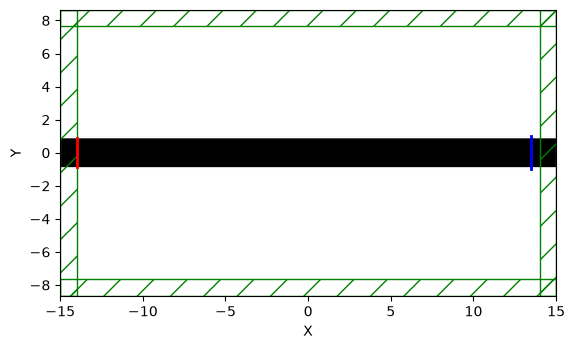

-----------
Initializing structure...
Padding y to even number of grid points.
Halving computational cell along direction y
time for choose_chunkdivision = 0.000555 s
Working in 2D dimensions.
Computational cell is 30 x 17.3125 x 0 with resolution 16
     block, center = (0,0,0)
          size (1e+20,1.73205,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.76,6.76,6.76)
time for set_epsilon = 0.036114 s
-----------
field decay(t = 50.03125): 6.319914881335027e-08 / 6.319914881335027e-08 = 1.0
field decay(t = 100.0625): 0.07542904144288688 / 0.07542904144288688 = 1.0
field decay(t = 150.09375): 2.936715527692116 / 2.936715527692116 = 1.0
field decay(t = 200.125): 6.640693916143455e-05 / 2.936715527692116 = 2.2612656396318348e-05


field decay(t = 250.15625): 1.1137114836145303e-13 / 2.936715527692116 = 3.792371011467241e-14
run 0 finished at t = 250.15625 (8005 timesteps)
     block, center = (0,0,0)
          size (1e+20,1.73205,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.76,6.76,6.76)
     block, center = (0,0,0)
          size (40,17.3205,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.76,6.76,6.76)
     cylinder, center = (-20,0.866025,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-20,-0.866025,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-20.5,1.73205,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-20.5,-1.73205,0)
          radius 0

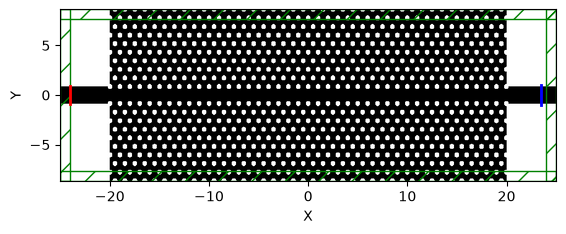

-----------
Initializing structure...
Padding y to even number of grid points.
Halving computational cell along direction y
time for choose_chunkdivision = 0.002775 s
Working in 2D dimensions.
Computational cell is 50 x 17.3125 x 0 with resolution 16
     block, center = (0,0,0)
          size (1e+20,1.73205,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.76,6.76,6.76)
     block, center = (0,0,0)
          size (40,17.3205,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.76,6.76,6.76)
     cylinder, center = (-20,0.866025,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-20,-0.866025,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-20.5,1.73205,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          d

,normalized_frequency,wavelength,transmittance
0,0.250000,1600.000000,0.063683
1,0.250200,1598.718462,0.054722
2,0.250401,1597.438976,0.046637
3,0.250601,1596.161535,0.043177
4,0.250802,1594.886137,0.039738


In [4]:
time_start = time.perf_counter()

a = 400
c_const = 299792458
freqs_wo, psd_out_wo = phc_trans(use_photonic_crystal=False, photonic_crystal_length=20, decay_check=10, decay_time=500)
freqs_w, psd_out_w = phc_trans(use_photonic_crystal=True, photonic_crystal_length=40, decay_check=20, decay_time=10000)

freqs = a / np.array(freqs_w)

df = pd.DataFrame()
df["normalized_frequency"] = np.array(freqs_w)
df["wavelength"] = freqs
df["transmittance"] = np.array(psd_out_w) / np.array(psd_out_wo)
df.to_csv(out_dir / "transmittance1.csv", index=False)

time_end = time.perf_counter()
elapsed_time = time_end - time_start
message = "The necessary time: {:.3f}s".format(elapsed_time)
print(message)

with open(out_dir / "totaltime1.txt", "w") as f:
    f.write(message)

df.head()

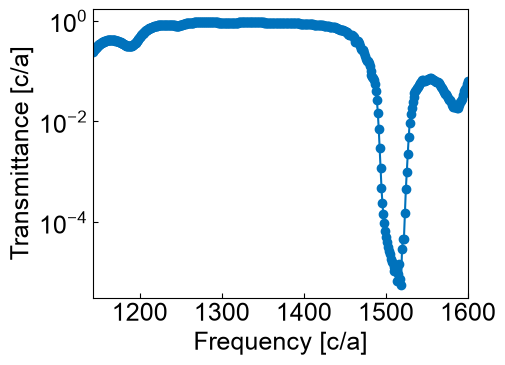

In [ ]:
plt.figure(figsize=(5.4, 4), dpi=100)
plt.plot(freqs, np.array(psd_out_w) / np.array(psd_out_wo), color="#0072bc")
plt.scatter(freqs, np.array(psd_out_w) / np.array(psd_out_wo), color="#0072bc")
plt.xlabel("Frequency [c/a]")
plt.ylabel("Transmittance [c/a]")
plt.xlim([freqs[-1], freqs[0]])
plt.yscale("log")
plt.tight_layout()
plt.savefig(fig_dir / "phcwaveguide_transmittance1.png")
plt.show()